In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
HBAR = 1.054571817e-34
ELECTRON_MASS = 9.1093837e-31
EV_TO_JOULE = 1.602176634e-19
NM_TO_METRE = 1e-9

In [63]:
def calculate_well_strength(depth_ev,width_nm,mass_ratio=1.0):
    if depth_ev <= 0:
        raise ValueError("Well depth must be greater than zero.")
    if width_nm <= 0:
        raise ValueError("Well width must be greater than zero.")
    if mass_ratio <= 0:
        raise ValueError("Mass ratio must be greater than zero.")

    depth_joule = depth_ev*EV_TO_JOULE
    width_metre = width_nm*NM_TO_METRE
    half_width = width_metre/2
    particle_mass = mass_ratio*ELECTRON_MASS
    z0 = (half_width*np.sqrt(2*particle_mass*depth_joule)/HBAR)

    return z0,half_width,particle_mass

In [4]:
def even_transcendental(z,z0):
  z_arr = np.asarray(z,dtype=float)

  if z0 <= 0:
    raise ValueError("z0 must be greater than zero.")
  if np.any(z_arr <= 0) or np.any(z_arr >= z0):
    raise ValueError("All values of z must lie in interval (0,z0)")

  sqrt_term = np.sqrt(np.clip(z0**2- z_arr**2,0.0,None))
  f_even    = z_arr*np.tan(z_arr) - sqrt_term

  return f_even

In [5]:
def odd_transcendental(z,z0):
  z_arr = np.asarray(z,dtype=float)

  if z0 <= 0:
    raise ValueError("z0 must be greater than zero.")
  if np.any(z_arr <= 0) or np.any(z_arr >= z0):
    raise ValueError("All values of z must lie in interval (0,z0)")

  sqrt_term = np.sqrt(np.clip(z0**2- z_arr**2,0.0,None))
  f_odd   = -z_arr/np.tan(z_arr) - sqrt_term

  return f_odd

In [6]:
def bisection_method(function,left,right,z0,tolerance=1e-10,max_iterations=1000):
    error = abs(right - left)
    itr   = 0
    f_left  = function(left,z0)
    f_right = function(right,z0)

    if f_left*f_right>0:
        raise ValueError("Root doesn't exist in given interval")

    elif abs(f_left) < tolerance:
        return left

    elif abs(f_right) < tolerance:
        return right

    else:
        while error > tolerance and itr < max_iterations:
            c   = (left+right)/2
            f_c = function(c,z0)

            if abs(f_c) < tolerance:
                return c

            elif f_left*f_c < 0:
                right = c
                f_right = f_c
                error = abs(right - left)

            else:
                left = c
                f_left = f_c
                error = abs(right - left)
            itr += 1

    if error <= tolerance:
      return (left + right) / 2

    raise RuntimeError("Bisection method did not converge within max_iterations.")

In [7]:
def intervals(z0):
    step = np.pi/2
    z_val = np.arange(0,z0,step)

    z_even = []
    z_odd  = []
    for i in range(len(z_val) - 1):
        tele = (z_val[i],z_val[i+1])
        if i%2 == 0:
            z_even.append(tele)
        else:
            z_odd.append(tele)
    z_odd.append((z_val[-1],z0))

    return z_even,z_odd


In [8]:
def sign_check(even_intervals,odd_intervals,z0):
    even_valid_intervals = []
    odd_valid_intervals  = []
    epsilon = 1e-10

    for i in range(len(even_intervals)):
        ele_even = even_intervals[i]

        left_e  = ele_even[0] + epsilon
        right_e = ele_even[1] - epsilon

        left_even  = even_transcendental(left_e,z0)
        right_even = even_transcendental(right_e,z0)

        if left_even*right_even < 0:
            even_valid_intervals.append((left_e,right_e))

    for j in range(len(odd_intervals)):
        ele_odd  = odd_intervals[j]

        left_o  = ele_odd[0] + epsilon
        right_o = ele_odd[1] - epsilon

        left_odd  = odd_transcendental(left_o,z0)
        right_odd = odd_transcendental(right_o,z0)

        if left_odd*right_odd < 0:
            odd_valid_intervals.append((left_o,right_o))
            
    return even_valid_intervals,odd_valid_intervals



In [9]:
def finding_roots(even_valid_intervals,odd_valid_intervals,z0):
    even_roots = []
    odd_roots  = []

    for i in range(len(even_valid_intervals)):
        ele   = even_valid_intervals[i]    
        left  = ele[0]
        right = ele[1] 
        root  = bisection_method(even_transcendental,left,right,z0)
        even_roots.append(root)

    for i in range(len(odd_valid_intervals)):
        ele   = odd_valid_intervals[i]    
        left  = ele[0]
        right = ele[1] 
        root  = bisection_method(odd_transcendental,left,right,z0)
        odd_roots.append(root)

    return even_roots,odd_roots

In [10]:
def energy_from_z(z,half_width,mass,depth):
    E_rel_num = (HBAR**2)*(z**2)
    E_rel_den = 2*mass*(half_width**2)

    E_rel_J = E_rel_num/E_rel_den
    E_rel_ev = E_rel_J/EV_TO_JOULE

    E = -depth + E_rel_ev

    return E



In [11]:
def energy_of_roots(even_roots,odd_roots,half_width,mass,depth):
    even_energies = []
    odd_energies  = []

    for root1 in even_roots:
        energy_val = energy_from_z(root1,half_width,mass,depth)
        even_energies.append(energy_val)

    for root2 in odd_roots:
            energy_val = energy_from_z(root2,half_width,mass,depth)
            odd_energies.append(energy_val)

    return even_energies,odd_energies

In [48]:
def Final_energies(even_roots,odd_roots,even_energies,odd_energies):

    Energies = even_energies + odd_energies
    Roots = even_roots + odd_roots

    x = len(Energies)
    n = len(even_energies)

    Final_list = []

    for i in range(x):
        if i < n:
            Final_list.append((Energies[i],"even",Roots[i]))
        else:
            Final_list.append((Energies[i],"odd",Roots[i]))

    Final_list.sort()
    return Final_list

In [51]:
def wave_parameters(z,energy,half_width,mass):
    k = z/half_width
    energy = energy*EV_TO_JOULE
    kappa = np.sqrt(-2*mass*energy)/HBAR

    return k,kappa

In [55]:
def normalization_even(z,half_width,kappa):
    first_term = half_width
    second_term = (half_width*np.sin(2*z))/(2*z)
    third_term  = (np.cos(z))**2/kappa

    A_even = 1/np.sqrt(first_term + second_term + third_term)

    return A_even

def normalization_odd(z,half_width,kappa):
    first_term = half_width
    second_term = (half_width*np.sin(2*z))/(2*z)
    third_term  = (np.sin(z))**2/kappa

    A_odd  = 1/np.sqrt(first_term - second_term + third_term)

    return A_odd


In [70]:
def wavefunction_even(x, z, half_width, kappa, A):
    k = z / half_width

    inside = A * np.cos(k * x)
    outside = (A*np.cos(z)*np.exp(-kappa*(np.abs(x) - half_width)))

    return np.where(np.abs(x) <= half_width,inside,outside)


def wavefunction_odd(x, z, half_width, kappa, A):
    k = z / half_width

    inside = A * np.sin(k * x)

    outside = (np.sign(x)*A*np.sin(z)*np.exp(-kappa * (np.abs(x) - half_width)))

    return np.where(np.abs(x) <= half_width,inside,outside)


In [65]:
def solve_finite_well(depth_ev,width_nm,mass_ratio):
    z0,half_width,particle_mass = calculate_well_strength(depth_ev,width_nm,mass_ratio)
    z_even,z_odd = intervals(z0)
    even_valid_intervals,odd_valid_intervals = sign_check(z_even,z_odd,z0)
    even_roots,odd_roots = finding_roots(even_valid_intervals,odd_valid_intervals,z0)
    states = []
    for i in range(len(even_roots)):
        z = even_roots[i]
        energy_val = energy_from_z(z,half_width,particle_mass,depth_ev)
        k,kappa = wave_parameters(z,energy_val,half_width,particle_mass)
        A = normalization_even(z,half_width,kappa)
        state = {"E":energy_val,"parity":"even","z":z,"k":k,"kappa":kappa,"A":A}
        states.append(state)

    for j in range(len(odd_roots)):
        z = odd_roots[j]
        energy_val = energy_from_z(z,half_width,particle_mass,depth_ev)
        k,kappa = wave_parameters(z,energy_val,half_width,particle_mass)
        A = normalization_odd(z,half_width,kappa)
        state = {"E":energy_val,"parity":"odd","z":z,"k":k,"kappa":kappa,"A":A}
        states.append(state)
    states.sort(key=lambda state: state["E"])

    return states

In [69]:
def get_wavefunction(x,states,state_index,half_width):
    state = states[state_index]
    parity = state["parity"]
    energy = state["E"]
    A = state["A"]
    kappa = state["kappa"]
    z = state["z"]

    if parity == "even":
        wave_function = wavefunction_even(x,z,half_width,kappa,A)
    else:
        wave_function = wavefunction_odd(x,z,half_width,kappa,A)

    return wave_function,energy

In [ ]:
def plot_state(states, state_index, half_width):
    state = states[state_index]

    x = np.linspace(-3*half_width,3*half_width,1000)

    wave_function, energy = get_wavefunction(x,states,state_index,half_width)

    plt.figure(figsize=(9, 5))

    plt.plot(x*1e9,wave_function,label=f"E = {energy:.4f}eV")
    plt.axvline(-half_width * 1e9,linestyle="--",alpha=0.6)
    plt.axvline(half_width * 1e9,linestyle="--",alpha=0.6)
    plt.axhline(0, linewidth=0.8)
    plt.xlabel("x (nm)")
    plt.ylabel(r"$\psi(x)$")
    plt.title(f"State {state_index}({state['parity']})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

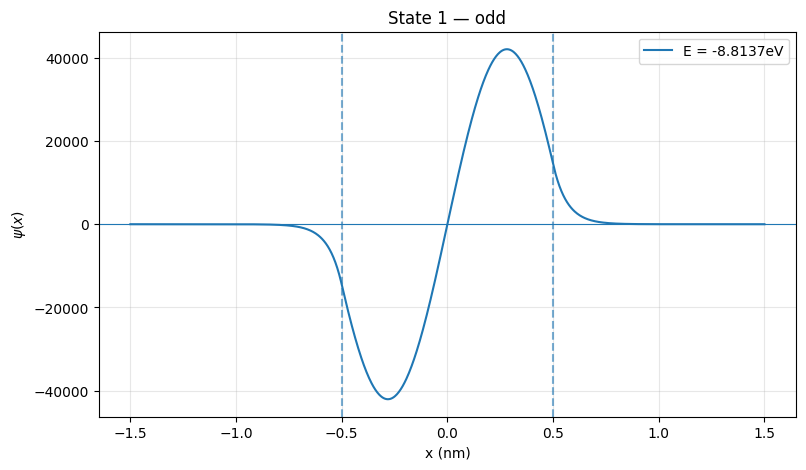

In [79]:
depth_ev = 10.0
width_nm = 1.0
mass_ratio = 1.0
states = solve_finite_well(depth_ev, width_nm, mass_ratio)
z0, half_width ,particle_mass = calculate_well_strength(depth_ev=10,width_nm=1,mass_ratio=1)
plot_state(states, 1, half_width)
